In [1]:
!uv pip install langgraph langchain-mistralai dotenv --quiet

In [2]:
from langgraph.graph import StateGraph, START, END
from langchain_mistralai import ChatMistralAI
from typing import TypedDict
from dotenv import load_dotenv

In [3]:
load_dotenv()

True

In [4]:
model = ChatMistralAI()

In [5]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [6]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [7]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [8]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()

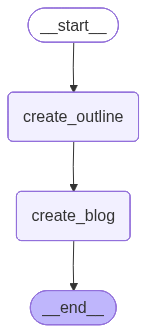

In [9]:
workflow

In [10]:
intial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': '# **Blog Outline: The Rise of AI in India – Opportunities, Challenges, and Future Outlook**\n\n## **Title:**\n**"The Rise of AI in India: Transforming Industries, Empowering Innovation, and Shaping the Future"**\n\n## **Meta Description:**\nExplore how AI is reshaping India’s economy, from healthcare and agriculture to finance and education. Discover key trends, challenges, government initiatives, and the future of AI in India.\n\n---\n\n## **1. Introduction**\n- **Hook:** *"From chatbots handling customer queries to AI-powered drones monitoring crops, artificial intelligence is no longer a futuristic concept—it’s a present-day reality in India."*\n- **Brief Overview:** AI is revolutionizing industries, improving efficiency, and creating new economic opportunities in India.\n- **Key Statistics:**\n  - India’s AI market size (2023-2024 estimates).\n  - Expected growth rate (CAGR) by 2030.\n  - Comparison with global AI adoption.\n- **Thesis S

In [11]:
print(final_state['outline'])

# **Blog Outline: The Rise of AI in India – Opportunities, Challenges, and Future Outlook**

## **Title:**
**"The Rise of AI in India: Transforming Industries, Empowering Innovation, and Shaping the Future"**

## **Meta Description:**
Explore how AI is reshaping India’s economy, from healthcare and agriculture to finance and education. Discover key trends, challenges, government initiatives, and the future of AI in India.

---

## **1. Introduction**
- **Hook:** *"From chatbots handling customer queries to AI-powered drones monitoring crops, artificial intelligence is no longer a futuristic concept—it’s a present-day reality in India."*
- **Brief Overview:** AI is revolutionizing industries, improving efficiency, and creating new economic opportunities in India.
- **Key Statistics:**
  - India’s AI market size (2023-2024 estimates).
  - Expected growth rate (CAGR) by 2030.
  - Comparison with global AI adoption.
- **Thesis Statement:** AI is transforming India’s digital economy, but ch

In [12]:
print(final_state['content'])

# **The Rise of AI in India: Transforming Industries, Empowering Innovation, and Shaping the Future**

---

## **Introduction: The AI Revolution in India**

Artificial Intelligence (AI) is no longer a distant dream—it’s a reality reshaping India’s economy, society, and future. From AI-powered chatbots handling customer queries to drones monitoring crops and deep learning models detecting diseases, AI is transforming industries at an unprecedented pace.

India’s AI market is projected to grow at a **compound annual growth rate (CAGR) of 25-30%** from 2023 to 2030, reaching a valuation of **$17 billion by 2030** (according to a report by **PwC and NASSCOM**). This growth is fueled by a **young, tech-savvy population, increasing smartphone penetration, government initiatives, and a thriving startup ecosystem**.

Yet, challenges remain—**data privacy concerns, skill gaps, infrastructure limitations, and ethical dilemmas**—that must be addressed for sustainable AI adoption. This blog explor